In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [2]:
from google.colab import files
uploaded = files.upload()


Saving dataset.csv to dataset.csv


In [3]:
dataset1 = pd.read_csv('dataset.csv')
X = dataset1[['input']].values
y = dataset1[['Output']].values
print(X)
print(y)

[[ 1]
 [ 2]
 [ 3]
 [ 4]
 [ 5]
 [ 6]
 [ 7]
 [ 8]
 [ 9]
 [10]
 [11]
 [12]
 [13]
 [14]
 [15]
 [16]]
[[11]
 [12]
 [13]
 [14]
 [15]
 [16]
 [17]
 [18]
 [19]
 [20]
 [21]
 [22]
 [23]
 [24]
 [25]
 [26]]


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33,
random_state=33)

In [5]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [16]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [25]:
#Name: AMIRTHA VARSHINI M
#Register Number: 212224230017
class NeuralNet(nn.Module):
  def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(1, 8)
        self.fc2 = nn.Linear(8, 10)
        self.fc3 = nn.Linear(10, 1)
        self.relu = nn.ReLU()
        self.history = {'loss': []}
  def forward(self,x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [18]:
amirtha_brain=NeuralNet()
criterion = nn.MSELoss()
optimizer = optim.RMSprop(amirtha_brain.parameters(), lr=0.001)

In [19]:
#Name: AMIRTHA VARSHINI M
#Register Number: 212224230017
def train_model(amirtha_brain, X_train, y_train, criterion, optimizer, epochs=2000):
    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(amirtha_brain(X_train), y_train)
        loss.backward()
        optimizer.step()
        amirtha_brain.history['loss'].append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item():.6f}')

In [20]:
train_model(amirtha_brain, X_train_tensor, y_train_tensor, criterion, optimizer)

Epoch [0/2000], Loss: 326.004547
Epoch [200/2000], Loss: 264.924194
Epoch [400/2000], Loss: 156.278564
Epoch [600/2000], Loss: 51.088921
Epoch [800/2000], Loss: 3.556127
Epoch [1000/2000], Loss: 0.037181
Epoch [1200/2000], Loss: 0.017008
Epoch [1400/2000], Loss: 0.002248
Epoch [1600/2000], Loss: 0.000009
Epoch [1800/2000], Loss: 0.000000


In [22]:
with torch.no_grad():
    test_loss = criterion(amirtha_brain(X_test_tensor), y_test_tensor)
    print(f'Test Loss: {test_loss.item():.6f}')
loss_df = pd.DataFrame(amirtha_brain.history)



Test Loss: 0.000000


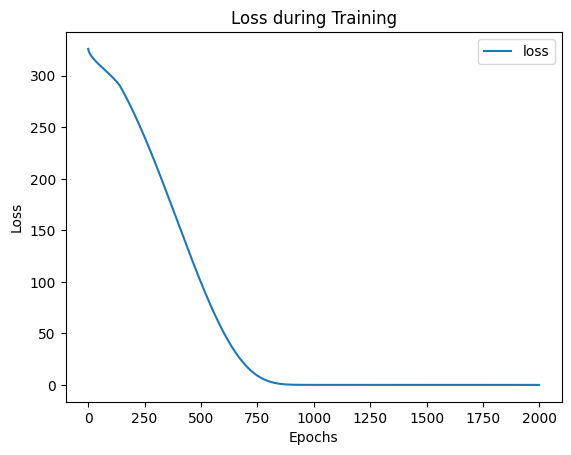

In [23]:
import matplotlib.pyplot as plt
loss_df.plot()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss during Training")
plt.show()

In [24]:
X_n1_1 = torch.tensor([[9]], dtype=torch.float32)
prediction = amirtha_brain(torch.tensor(scaler.transform(X_n1_1),
dtype=torch.float32)).item()
print(f'Prediction: {prediction}')

Prediction: 19.000001907348633
